# Coding an LLM architecture

In [1]:
GPT_CONFIG_124m = {
    "vocab_size": 50_257,   # number of unique token IDs the tokenizer/model supports
    "context_length": 1024, # maximum number of tokens the model can process at once
    "emb_dim": 768,         # size of each token and postional embedding
    "n_heads": 12,          # number of attention heads in each multi-head attention layer
    "n_layers": 12,         # number of transformer blocks stacked in the model
    "drop_rate": 0.1,       # dropout probability used for regularization
    "qkv_bias": False,      # whether query/key/value linear layers use bias terms.
}

In [2]:
import torch
import torch.nn as nn

class DummyGTPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x
    
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x

In [5]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
text1 = "Every effort moves you"
text2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(text1)))
batch.append(torch.tensor(tokenizer.encode(text2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)



(process:27632): Pango-WARNING **: 22:50:01.067: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


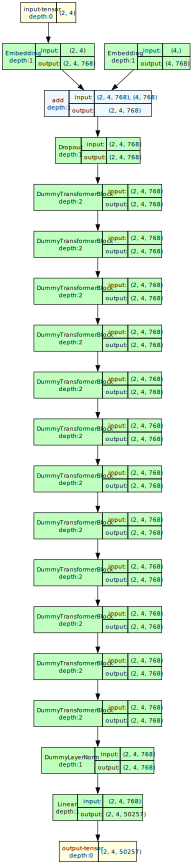

In [20]:
import torchview as tv
torch.manual_seed(123)
model = DummyGTPModel(GPT_CONFIG_124m)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)
mock_batch = torch.randint(0, GPT_CONFIG_124m["vocab_size"], (2,4), dtype=torch.long)
graph_model = tv.draw_graph(model, input_data=batch)
graph_model.visual_graph